# Final Group Project
## By: Megan Wangsawijaya, Kaci Moy, Trang Kieu, Pete Namchaisiri

### Chosen Data Set
Data set: https://www.kaggle.com/datasets/uciml/el-nino-dataset 
El Nino indices from 1870: https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.csv

### 1) Describe the dataset you chose. Why did you choose it? What features does it include? What year is it from? How was it collected? What should we know about this dataset as we read your write-up? (8pts)

- The dataset used in this project contains oceanographic and meteorological measurements collected from a network of buoys located throughout the equatorial Pacific Ocean. These measurements were gathered using the Tropical Atmosphere Ocean (TAO) array, which consists of nearly 70 moored buoys deployed across the Pacific Ocean to monitor climate conditions. The data was originally collected by the NOAA Pacific Marine Environmental Laboratory and is part of the UCI Machine Learning Repository. The TAO array was designed to measure environmental variables that influence large-scale climate patterns such as El Niño and La Niña, which are part of the El Niño Southern Oscillation (ENSO) system.
- In addition to the buoy measurements, we also used a second dataset containing the Niño 3.4 index, which measures sea surface temperature (SST) anomalies in the central Pacific Ocean. The Niño 3.4 index is widely used in climate science to monitor and identify El Niño and La Niña events. Positive SST anomalies greater than approximately +0.5 °C typically indicate El Niño conditions, while negative anomalies below −0.5 °C indicate La Niña conditions.
- We chose this dataset because one of our team members is interested in weather prediction, and we wanted to apply the machine learning concepts we learned in class to a real-world climate problem. In addition, three members of our team come from regions that are affected by El Niño, which made the topic personally meaningful to us. After further research, we found that predicting El Niño events is an important challenge in climate science. El Niño events can significantly influence global weather patterns, often leading to floods, droughts, and shifts in temperature across different regions of the world. By analyzing oceanographic and atmospheric measurements such as sea surface temperature, wind patterns, and humidity, machine learning models may be able to detect patterns associated with the development of El Niño conditions. This makes the dataset both scientifically meaningful and well-suited for building predictive models.
- The buoy dataset includes several environmental variables measured by the sensors. These include the date of observation, latitude and longitude of the buoy, zonal wind speed (east–west winds), meridional wind speed (north–south winds), relative humidity, air temperature, sea surface temperature, and subsurface ocean temperatures at depths down to approximately 500 meters. In some locations, additional measurements such as rainfall, solar radiation, and ocean current levels are also recorded.
- The dataset contains measurements taken as early as 1980, although the amount of data available varies depending on when individual buoys were deployed. All readings were taken at the same time of day to maintain consistency across observations. Because the buoy dataset contains daily measurements while the Niño 3.4 index is reported monthly, we aggregated the buoy observations to the monthly level before modeling. Monthly averages were calculated for each environmental variable so that the temporal resolution of the predictor variables matched the SST anomaly index.
- It is also important to note several limitations when working with this dataset. Some variables contain missing values because not all buoys measure every environmental condition. In addition, buoys may shift slightly from their original positions due to ocean movement. While latitude values typically remain within one degree of their intended location, longitude values may sometimes differ by up to five degrees. Finally, some buoys have longer historical records than others because they were installed earlier. Despite these limitations, the dataset provides valuable long-term measurements that can help analyze and predict climate patterns related to El Niño.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Read CSV Data

In [97]:
# read in csv data from Kaggle & NOAA Physical Sciences Laboratory 
elnino = pd.read_csv("elnino.csv") # predictor variables
nino_ind = pd.read_csv("nino34.csv") # target data

In [98]:
elnino.head()

,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [99]:
nino_ind.head()

,Date,NINA34 missing value -99.99 https://psl.noaa.gov/data/timeseries/month/
0,1870-01-01,-1.00
1,1870-02-01,-1.20
2,1870-03-01,-0.83
3,1870-04-01,-0.81
4,1870-05-01,-1.27


### 2) Define a research question. What are you trying to predict? Describe what you’re trying to accomplish (it will differ between Supervised and Unsupervised learning). (4pts)

- Our data represents historical oceanographic measurements paired with the Niño 3.4 index, which measures sea surface temperature (SST) anomalies in the central Pacific Ocean. The Niño 3.4 index is calculated as a three-month rolling average of SST anomalies relative to a long-term climatological baseline. The index is centered around zero, where positive values indicate warmer than average ocean temperatures and negative values indicate cooler than average temperatures.

- Climate scientists commonly use thresholds of approximately +0.5 °C and −0.5 °C to identify El Niño and La Niña events. When the SST anomaly exceeds +0.5 °C for a sustained period, it is typically classified as an El Niño event. Similarly, anomalies below −0.5 °C indicate La Niña conditions. Larger positive or negative anomalies correspond to stronger climate events.

- Our research question is: **How accurately can machine learning models estimate SST anomalies in order to predict the likelihood of an El Niño event using historical climate and oceanographic data?**

- Because the model learns from labeled historical oceanographic observations paired with SST anomaly values, this problem is treated as a **supervised learning task**.

- To answer our research question, the project will:

    - Train predictive models using historical indicators such as zonal winds, meridional winds, relative humidity, air temperature, sea surface temperature, and subsurface temperatures.
    - Evaluate predictive accuracy by testing how well the models estimate SST anomalies on data that was not included during training.
    - Use the trained models to estimate SST anomaly values and assess whether these estimates indicate the presence of El Niño conditions.

# Clean Predictor Data

In [100]:
# remove leading and trailing spaces in column names
elnino.columns = elnino.columns.str.strip()
print(elnino.columns.tolist())

['Observation', 'Year', 'Month', 'Day', 'Date', 'Latitude', 'Longitude', 'Zonal Winds', 'Meridional Winds', 'Humidity', 'Air Temp', 'Sea Surface Temp']


In [101]:
# replace '.' with NaN
elnino = elnino.replace('.', np.nan)

# convert numeric columns where possible
for col in elnino.columns:
    try:
        elnino[col] = pd.to_numeric(elnino[col])
    except:
        pass  # leave non-numeric columns unchanged

# drop Day and Date
elnino = elnino.drop(columns=["Day", "Date", "Observation"])

# # remove data outside of El Niño 3.4 bounds
# elnino = elnino[(elnino['Latitude'] <= -5) | (elnino['Latitude'] >= 5)]
# elnino = elnino[(elnino['Longitude'] >= -170) | (elnino['Longitude'] <= -120)]

# elnino.head()

Above, we commented out the removal of observations with latitudes and longitudes outside the bounds of El Niño 3.4 data. We wanted to test whether the predictions would estimate better with data only coming from the bounds of 3.4 data; however, we found the opposite to be true. Inclusion of data out of the El Niño 3.4 bounds observes more accurate predictions (as we tested with out actual v. prediction graphs). Thus, we decided to keep our predictor data inlusive of all bounds of El Niño.

In [102]:
# elnino.info()

In [103]:
# group by Year and Month, compute means
agg_elnino = elnino.groupby(["Year", "Month"], as_index=False).mean()

# remove humidity -- many NaNs
agg_elnino = agg_elnino.drop(columns=["Humidity"])

# fix Year
agg_elnino.Year = agg_elnino.Year + 1900

In [104]:
agg_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000


In [105]:
agg_elnino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              211 non-null    int64  
 1   Month             211 non-null    int64  
 2   Latitude          211 non-null    float64
 3   Longitude         211 non-null    float64
 4   Zonal Winds       211 non-null    float64
 5   Meridional Winds  211 non-null    float64
 6   Air Temp          211 non-null    float64
 7   Sea Surface Temp  208 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 13.3 KB


# Clean Target Data

In [106]:
print(nino_ind.columns.tolist())

['Date', '   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/']


In [107]:
# add Year and Month columns to merge predictor and target data
nino_ind['Year'] = nino_ind['Date'].str.split('-').str[0].astype(int)
nino_ind['Month'] = nino_ind['Date'].str.split('-').str[1].astype(int)

In [108]:
# drop Date columns
nino_ind = nino_ind.drop(columns=["Date"])

In [109]:
# rename indices column
nino_ind = nino_ind.rename(columns={"   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/": "NINA34"})

# reorder columns
nino_ind = nino_ind[['Year', 'Month', 'NINA34']]

In [110]:
nino_ind.head()

,Year,Month,NINA34
0,1870,1,-1.00
1,1870,2,-1.20
2,1870,3,-0.83
3,1870,4,-0.81
4,1870,5,-1.27


In [111]:
nino_ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1872 entries, 0 to 1871
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    1872 non-null   int64  
 1   Month   1872 non-null   int64  
 2   NINA34  1872 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 44.0 KB


# Merge Predictor & Target Data

In [112]:
# merge the data with the El Niño data
clean_elnino = agg_elnino.merge(nino_ind, on=["Year","Month"])

clean_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp,NINA34
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667,0.09
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429,-0.23
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333,-0.12
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129,-0.11
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000,0.10


In [113]:
# drop rows with NaN
clean_elnino = clean_elnino.dropna()

In [114]:
clean_elnino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 210
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              208 non-null    int64  
 1   Month             208 non-null    int64  
 2   Latitude          208 non-null    float64
 3   Longitude         208 non-null    float64
 4   Zonal Winds       208 non-null    float64
 5   Meridional Winds  208 non-null    float64
 6   Air Temp          208 non-null    float64
 7   Sea Surface Temp  208 non-null    float64
 8   NINA34            208 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 16.2 KB


In [115]:
# add classification target variable if we want to do classification
class_list = []

for index in clean_elnino.NINA34:
    if (index >= 0.05) | (index <= -0.05):
        class_list.append(1)
    else:
        class_list.append(0)

clean_elnino['Event'] = class_list

In [116]:
clean_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp,NINA34,Event
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667,0.09,1
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429,-0.23,1
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333,-0.12,1
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129,-0.11,1
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000,0.10,1


We added an Event column that identifies whether an El Niño or La Niña event occured (1) or not (0) within that Month and Year. After training our data with a Random Forest Classifier model, the model was not successful as it always predicted an El Niño or La Niña event. Thus, we will not be using that column further and only utilized it for testing a Random Forest Classifier model. 

### Why is this algorithm a good way of answering your research question? (4pts)

- We used two machine learning approaches: **Linear Regression**, and **Random Forest Regression**. These algorithms were selected to explore both interpretable linear relationships and more complex nonlinear patterns between climate variables and El Niño indicators.
- **Linear Regression** serves as a useful baseline model because it provides a clear and interpretable way to examine how climate variables relate to sea surface temperature (SST) anomalies. Since our goal is to estimate a continuous outcome (the Niño 3.4 SST anomaly index), regression-based methods allow us to quantify how predictors such as zonal winds, meridional winds, air temperature, and sea surface temperature influence SST changes. Linear regression captures linear relationships between these environmental variables and SST anomalies, helping us understand the relative contribution of each feature.
- However, climate systems such as El Niño are driven by complex and nonlinear interactions between atmospheric and oceanic processes. To account for these nonlinear relationships, we also implemented a **Random Forest model**. **Random Forest Regression** allows the model to capture more complex patterns and interactions between variables that linear regression may not detect. Because it builds an ensemble of decision trees, it can model nonlinear relationships and interactions among predictors while reducing overfitting through averaging.
- Ultimately, regression models help estimate the magnitude of SST anomalies.

# Linear Regression Model

In [117]:
# define model features
features = ['Zonal Winds', 'Meridional Winds', 'Air Temp', 'Sea Surface Temp']

# define X, y
X = clean_elnino[features]
y = clean_elnino['NINA34']

In [118]:
# split training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [119]:
# calculate MSE and r2 score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.28007525815411194
R² Score: 0.5484354911328657


### Hyperparameter Sensitivity Analysis

This hyperparameter sensistivity analysis tests whether features including the winds and air temp actually affect El Niño or La Niña events. These weather events are primarily driven by sea surface temperature, as indicated by the index (target variable) that meaasure the changes in sea surface temperature (SST). 

In [120]:
# define model features - we only want Sea Surface Temp
features = ['Sea Surface Temp']

# define X, y
X1 = clean_elnino[features]
y1 = clean_elnino['NINA34']

In [121]:
# split training and testing data
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

# fit linear regression model
model1 = LinearRegression()
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)

In [122]:
# calculate MSE and r2 score
mse1 = mean_squared_error(y_test1, y_pred1)
r2_1 = r2_score(y_test1, y_pred1)

print("Mean Squared Error:", mse1)
print("R² Score:", r2_1)

Mean Squared Error: 0.5216722124126408
R² Score: 0.158909437626499


### Visualizations

Based on the MSE and R² Score, the model performed better with all the features as opposed to just Sea Surface Temp. Thus, moving forward, we will use the model with all features including zonal winds, meridional winds, air temp, and sea surface temp.

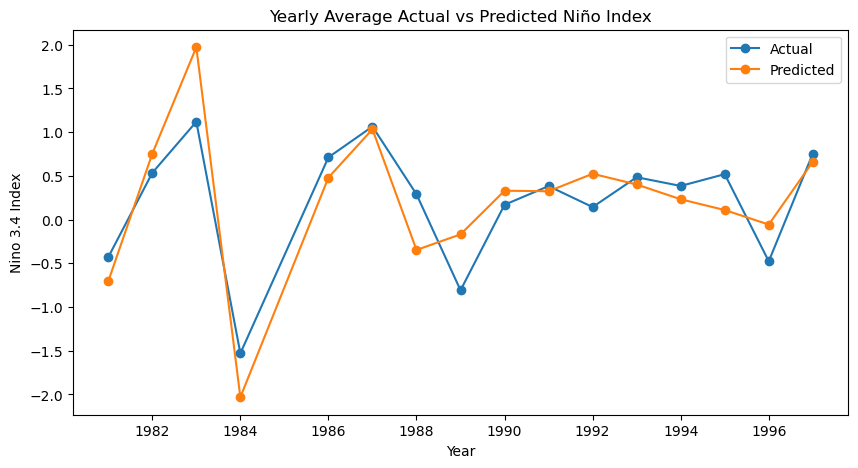

In [123]:
# plot time series actual v. predicted Niño index
results = pd.DataFrame({
    "Year": clean_elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred
})

yearly = results.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly["Year"], yearly["Actual"], marker='o', label="Actual")
plt.plot(yearly["Year"], yearly["Predicted"], marker='o', label="Predicted")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Yearly Average Actual vs Predicted Niño Index")

plt.legend()
plt.show()

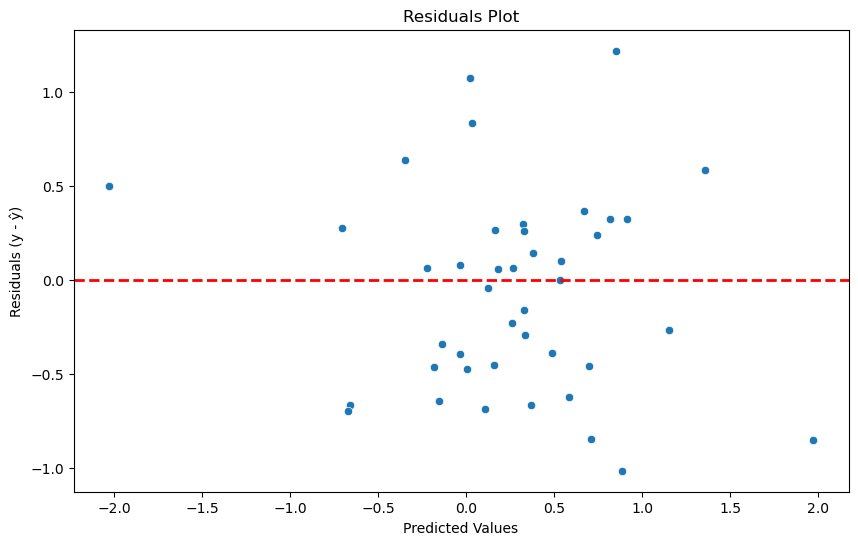

In [124]:
# plot residuals
residuals = y_test - y_pred

plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_pred, y = residuals)
plt.axhline(0, color = 'red', linestyle = '--', linewidth = 2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals Plot")
plt.show()

# Random Forest Regressor Model

In [125]:
# fit random forest regression model
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [126]:
# calculate MSE and r2 score
mse2 = mean_squared_error(y_test, y_pred_rf)
r2_2 = r2_score(y_test, y_pred_rf)

print("Mean Squared Error:", mse2)
print("R² Score:", r2_2)

Mean Squared Error: 0.25733042738095235
R² Score: 0.5851069143961674


### Hyperparameter Sensitivity Analysis

Similar to the last model, this hyperparameter sensistivity analysis will test whether features including the winds and air temp actually affect El Niño or La Niña events. These weather events are primarily driven by sea surface temperature, as indicated by the index (target variable) that meaasure the changes in sea surface temperature (SST).

In [127]:
# fit random forest regression model
model_rf1 = RandomForestRegressor()
model_rf1.fit(X_train1, y_train1)
y_pred_rf1 = model_rf1.predict(X_test1)

In [128]:
# calculate MSE and r2 score
mse1 = mean_squared_error(y_test1, y_pred_rf1)
r2_1 = r2_score(y_test1, y_pred_rf1)

print("Mean Squared Error:", mse1)
print("R² Score:", r2_1)

Mean Squared Error: 0.6307879350000002
R² Score: -0.01701751859442835


### Visualizations

Based on the MSE and R² Score, the model performed better with all the features as opposed to just Sea Surface Temp. Thus, moving forward, we will use the model with all features including zonal winds, meridional winds, air temp, and sea surface temp.

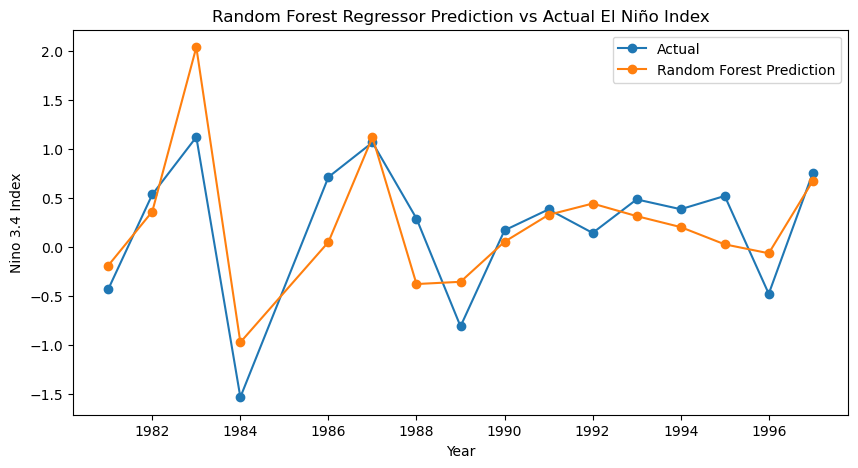

In [129]:
# plot time series actual v. predicted Niño index
results_rf = pd.DataFrame({
    "Year": clean_elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred_rf
})

results_rf = results_rf.sort_values("Year")

# Yearly average to reduce noise
yearly_rf = results_rf.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly_rf["Year"], yearly_rf["Actual"], marker='o', label="Actual")
plt.plot(yearly_rf["Year"], yearly_rf["Predicted"], marker='o', label="Random Forest Prediction")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Random Forest Regressor Prediction vs Actual El Niño Index")

plt.legend()
plt.show()

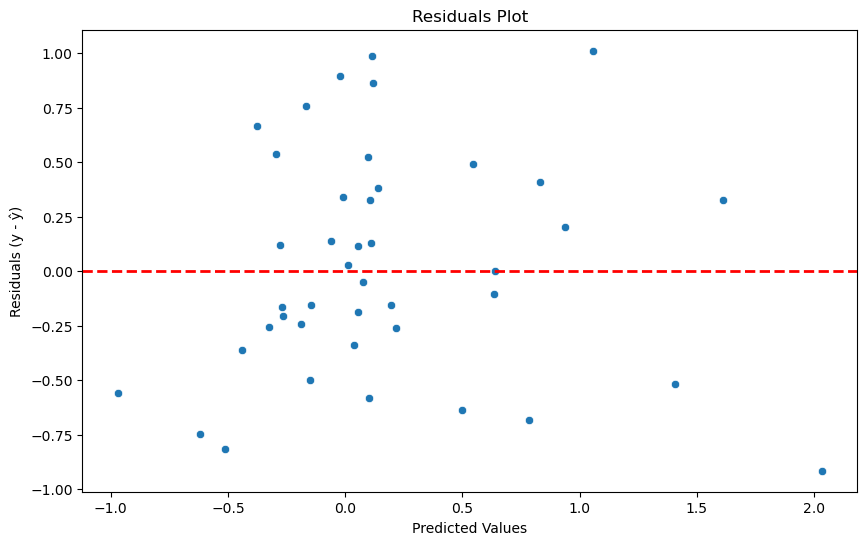

In [130]:
# plot residuals
residuals_rf = y_test - y_pred_rf

plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_pred_rf, y = residuals_rf)
plt.axhline(0, color = 'red', linestyle = '--', linewidth = 2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals Plot")
plt.show()